# 02 — Analyze Data

This notebook compares commute time and public-transit use between Bronx and Manhattan census tracts and creates the final project figures.

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
def borough_mean(data, variable):
    return data.groupby("Borough")[variable].mean()

In [67]:
df = pd.read_csv("../data/acs2015_bronx_manhattan_clean.csv")

In [68]:
print(df.shape)
print(df["Borough"].value_counts())

(602, 8)
Borough
Bronx        327
Manhattan    275
Name: count, dtype: int64


## Summary Statistics

In [70]:
summary = df.groupby("Borough")[[
    "MeanCommute",
    "Transit",
    "Poverty",
    "Unemployment",
    "WorkAtHome"
]].mean().round(2)

summary

,MeanCommute,Transit,Poverty,Unemployment,WorkAtHome
Borough,,,,,
Bronx,42.63,59.05,29.59,13.91,3.27
Manhattan,30.80,58.14,17.56,7.64,6.85


In [71]:
df.groupby("Borough")["Income"].median()

Borough
Bronx        33095.0
Manhattan    81250.0
Name: Income, dtype: float64

## Commute Time

In [73]:
commute = borough_mean(df, "MeanCommute")

commute

Borough
Bronx        42.632416
Manhattan    30.798909
Name: MeanCommute, dtype: float64

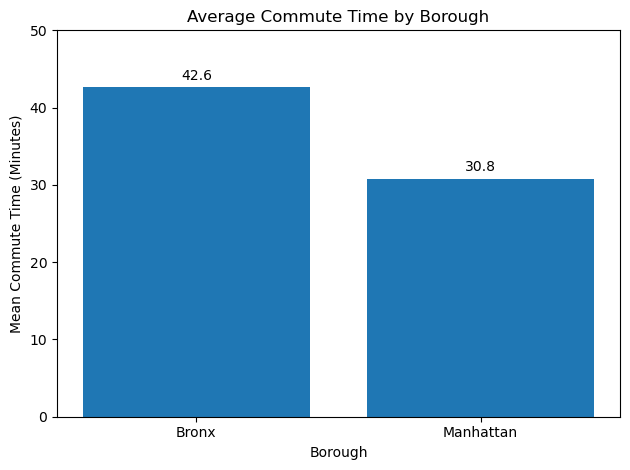

In [74]:
plt.bar(commute.index, commute.values)

plt.title("Average Commute Time by Borough")
plt.xlabel("Borough")
plt.ylabel("Mean Commute Time (Minutes)")

plt.ylim(0, 50)

plt.text(0, commute["Bronx"] + 1, round(commute["Bronx"], 1), ha="center")
plt.text(1, commute["Manhattan"] + 1, round(commute["Manhattan"], 1), ha="center")

plt.tight_layout()
plt.savefig("../output/mean_commute_by_borough.png", dpi=300)
plt.show()

## Public-Transit Use

In [76]:
transit = borough_mean(df, "Transit")

transit

Borough
Bronx        59.052294
Manhattan    58.144364
Name: Transit, dtype: float64

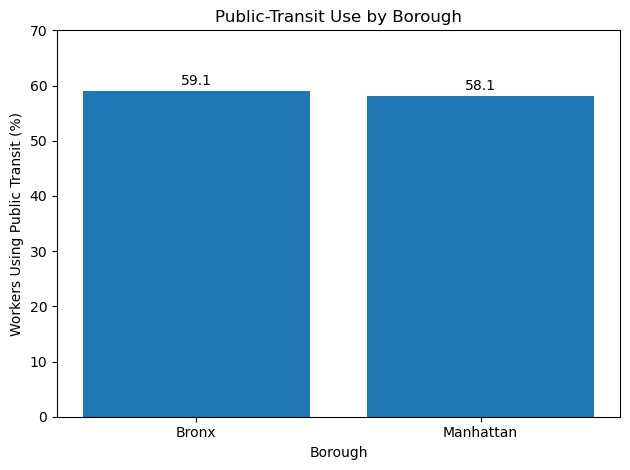

In [77]:
plt.bar(transit.index, transit.values)

plt.title("Public-Transit Use by Borough")
plt.xlabel("Borough")
plt.ylabel("Workers Using Public Transit (%)")

plt.ylim(0, 70)

plt.text(0, transit["Bronx"] + 1, round(transit["Bronx"], 1), ha="center")
plt.text(1, transit["Manhattan"] + 1, round(transit["Manhattan"], 1), ha="center")

plt.tight_layout()
plt.savefig("../output/transit_use_by_borough.png", dpi=300)
plt.show()

## Commute-Time Gap

In [79]:
commute_gap = commute["Bronx"] - commute["Manhattan"]

round(commute_gap, 2)

11.83

In [80]:
summary.to_csv("../output/borough_summary.csv")

## Main Finding

Bronx and Manhattan census tracts have similar levels of public-transit use, but Bronx census tracts have substantially longer average commute times. The average difference is approximately 11.8 minutes.